# 03 Modeling

# Conflict Escalation Forecasting

**District-level 14-day conflict escalation risk — South Asia, Sudan & South Sudan**

Data: [ACLED](https://acleddata.com) (acleddata.com), weekly aggregated admin-1 export.
All logic is imported from `src/` — this notebook only demonstrates the pipeline.

> **Reproducibility:** every stage is deterministic (fixed seed 42, chronological
> split, no shuffle). Running the full pipeline:
> `for s in ingest features labels split train compare explain visualize; do python run_pipeline.py --stage $s; done`


In [1]:
from __future__ import annotations
import sys
from pathlib import Path
_root = Path.cwd()
if not (_root / 'config.py').is_file():
    _root = _root.parent  # kernel cwd is notebooks/
sys.path.insert(0, str(_root))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
def show_inline():
    # src modules may force the Agg backend at import; re-assert
    # the inline backend right before displaying so plots embed.
    get_ipython().run_line_magic('matplotlib', 'inline')
    plt.show()
import config


## 1. Splits (chronological, no shuffle)

In [2]:
for name in ('train', 'val', 'test'):
    df = pd.read_parquet(config.DATA_PROCESSED_DIR / f'{config.SPLIT_FILE_PREFIX}_{name}.parquet')
    rate = 100 * df[config.LABEL_COLUMN].mean()
    print(f'{name:5s} {len(df):6d} rows  {df["event_date"].min().date()} -> {df["event_date"].max().date()}  pos {rate:.1f}%')
print('\nboundary invariant: max(train) < min(val) < min(test)')
train = pd.read_parquet(config.DATA_PROCESSED_DIR / 'split_train.parquet')
val = pd.read_parquet(config.DATA_PROCESSED_DIR / 'split_val.parquet')
test = pd.read_parquet(config.DATA_PROCESSED_DIR / 'split_test.parquet')
assert train['event_date'].max() < val['event_date'].min() < test['event_date'].min()
print('OK — strict temporal separation confirmed.')

train  30790 rows  2016-12-31 -> 2023-09-02  pos 69.2%
val     6522 rows  2023-09-09 -> 2025-02-01  pos 67.7%
test    6669 rows  2025-02-08 -> 2026-07-11  pos 67.3%

boundary invariant: max(train) < min(val) < min(test)
OK — strict temporal separation confirmed.


## 2. Winner model + test-window evaluation

In [3]:
import json
from src import models
from src.explainability import load_winning_model, load_test_window
comparison = json.loads((config.MODELS_DIR / config.MODEL_COMPARISON_FILE).read_text(encoding='utf-8'))
threshold = float(comparison['operating_threshold'])
print('winner:', comparison['winner'], '| operating threshold:', threshold)
model = load_winning_model()
test = load_test_window()
X, y, features = models.prepare_xy(test)
proba = models.predict_proba(model, X)
metrics = models.full_metrics(y, proba, threshold)
for k in ('precision', 'recall', 'f1', 'auc_pr', 'roc_auc', 'brier'):
    print(f'{k:9s} {metrics[k]:.4f}')

winner: xgboost | operating threshold: 0.25


precision 0.7683
recall    0.9311
f1        0.8419
auc_pr    0.8895
roc_auc   0.8042
brier     0.1806


## 3. Model comparison (from the M9 report)

In [4]:
row = lambda m: comparison[m]
print('LGBM  best-F1:', row('lightgbm')['threshold_analysis']['best_f1']['f1'], '@', row('lightgbm')['threshold_analysis']['best_f1']['threshold'])
print('XGB   best-F1:', row('xgboost')['threshold_analysis']['best_f1']['f1'], '@', row('xgboost')['threshold_analysis']['best_f1']['threshold'])
print('baselines:')
for name, b in comparison['baselines'].items():
    print(f'  {name:22s} F1 {b["f1"]:.4f}  PR-AUC {b["auc_pr"]:.4f}')

LGBM  best-F1: 0.8400080096115339 @ 0.2
XGB   best-F1: 0.8422891194903935 @ 0.25
baselines:
  always_positive        F1 0.8076  PR-AUC 0.6772
  event_count_heuristic  F1 0.8044  PR-AUC 0.7741
  majority               F1 0.8076  PR-AUC 0.6772
  persistence            F1 0.8261  PR-AUC 0.7557


## 4. SHAP explainability (full test window)

In [5]:
from src.explainability import compute_shap_values, mean_abs_importance
_, shap_values, base = compute_shap_values(model, X, features)
print('SHAP values shape:', shap_values.shape)
importance = mean_abs_importance(shap_values, features)
importance.head(10)

SHAP values shape: (6669, 33)


,feature,mean_abs_shap,share,rank
0,events_w30d,0.477194,0.166386,1
1,fatalities_w30d,0.420921,0.146765,2
2,velocity_events_w30d,0.309608,0.107953,3
3,events_w7d,0.178915,0.062383,4
4,spillover_w14d,0.154722,0.053948,5
5,admin1_code,0.151526,0.052834,6
6,events_w14d,0.148112,0.051643,7
7,velocity_fatalities_w30d,0.145428,0.050707,8
8,fatalities_w14d,0.128403,0.044771,9
9,month,0.114442,0.039903,10


## 5. Global importance chart

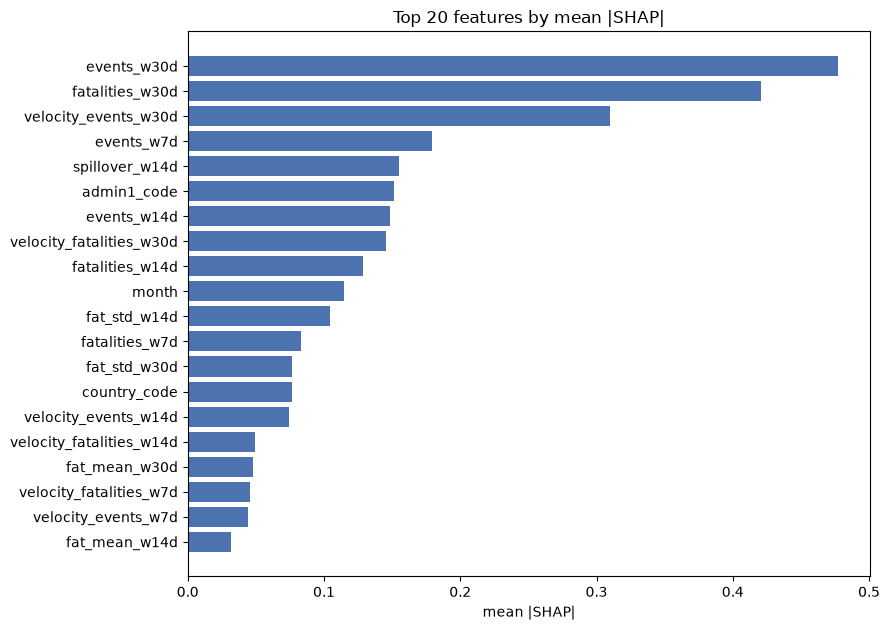

In [6]:
top = importance.head(config.SHAP_TOP_N).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, max(4, 0.32 * len(top))))
ax.barh(top['feature'], top['mean_abs_shap'], color='#4C72B0')
ax.set_xlabel('mean |SHAP|')
ax.set_title(f'Top {config.SHAP_TOP_N} features by mean |SHAP|')
plt.tight_layout()
show_inline()

## 6. Risk snapshot & artifacts

In [7]:
from src.visualization import build_prediction_table
centroids = (pd.read_parquet(config.DATA_PROCESSED_DIR / f'{config.CLEANED_EVENTS_FILE}.parquet')
             .groupby('geo_unit', as_index=False)[['latitude', 'longitude']]
             .mean().rename(columns={'latitude': 'lat', 'longitude': 'lon'}))
table = build_prediction_table(test, proba, shap_values, features, threshold, centroids)
print('geo units:', len(table))
print(table[['geo_unit', 'country', config.PREDICTION_PROBA_COLUMN, config.PREDICTION_CATEGORY_COLUMN, 'top_drivers']]
      .nlargest(5, config.PREDICTION_PROBA_COLUMN).to_string(index=False))

geo units: 122
          geo_unit  country    proba risk_category                                                                    top_drivers
Khyber Pakhtunkhwa Pakistan 0.999017      Critical              events_w30d: +1.901, fatalities_w30d: +1.517, events_w14d: +0.834
           Sagaing  Myanmar 0.997967      Critical               events_w30d: +1.399, fatalities_w30d: +1.044, events_w7d: +0.955
       Balochistan Pakistan 0.993424      Critical               fatalities_w30d: +1.409, events_w30d: +1.103, events_w7d: +0.922
    North Kordofan    Sudan 0.990908      Critical fatalities_w30d: +1.382, events_w30d: +1.136, velocity_fatalities_w30d: +0.688
            Magway  Myanmar 0.990577      Critical               fatalities_w30d: +1.287, events_w30d: +0.927, events_w7d: +0.638


## Summary
- Winner: **XGBoost**, validation F1 **0.8423** at operating threshold **0.25**; PR-AUC **0.9031**; beats all 4 baselines.
- SHAP: top drivers `events_w30d` / `fatalities_w30d` / `velocity_events_w30d` — sustained violence drives escalation.
- Risk snapshot: **Khyber Pakhtunkhwa (Pakistan, 0.999)** highest; **Zabul (Afghanistan, 0.026)** lowest.
- Full artifacts: `reports/maps/risk_map.html`, `reports/shap/` (21 plots), `reports/risk_summary.md`.